In [1]:
import sys
from pathlib import Path
import albumentations as A
import numpy as np
from ultralytics import YOLO
from ultralytics.models.yolo.detect import DetectionTrainer
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import torch
from PIL import Image
#from transformers import TrOCRProcessor, VisionEncoderDecoderModel

plt.show()

c:\Users\domag\Desktop\rac_vid_projekt\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
DATA_ROOT = Path("data").resolve()
YAML_PATH = DATA_ROOT / "data_local.yaml"
IMG_SIZE = 640
BATCH_SIZE = 8
EPOCHS = 30
NUM_WORKERS = 2
NUM_WEATHER_CORRUPTIONS = 3
CORRUPTION_PROB = 0.5

# (name, weights_file, use_weather_aug)
MODELS = [
    ("yolo26n", "yolo26n.pt", True),
    ("yolo26n_clean", "yolo26n.pt", False),
    ("yolo26s", "yolo26s.pt", True),
    ("yolo26s_clean", "yolo26s.pt", False),
]

In [3]:
class WeatherAugmentation:
    def __init__(self, weather_p=0.5, num_weather_corruptions=3):
        weather_effects = [
            A.RandomFog(fog_coef_range=(0.1, 0.5), alpha_coef=0.1, p=0.35),
            A.RandomRain(p=0.3),
            A.RandomSnow(snow_point_range=(0.3, 0.5), brightness_coeff=2.5, p=0.2),
            A.RandomSunFlare(p=0.2),
            A.RandomShadow(p=0.3),
            A.MotionBlur(blur_limit=(5, 20), p=0.4),
            A.GaussNoise(std_range=(0.01, 0.15), p=0.3),
            A.OneOf(
                [
                    A.RandomBrightnessContrast(
                        brightness_limit=(-0.4, 0.1), contrast_limit=(-0.2, 0.2), p=1.0
                    ),
                    A.RandomGamma(gamma_limit=(40, 180), p=1.0),
                ],
                p=0.5,
            ),
            A.Spatter(
                mode="mud", cutout_threshold=(0.7, 0.7), color=(120, 40, 40), p=0.2
            ),
        ]
        self.transform = A.Compose(
            [
                A.SomeOf(
                    weather_effects,
                    n=num_weather_corruptions,
                    replace=False,
                    p=weather_p,
                )
            ]
        )

    def __call__(self, labels):
        img = labels.get("img")
        if img is None:
            return labels

        is_float = img.dtype != np.uint8
        if is_float:
            img_u8 = (img * 255).clip(0, 255).astype(np.uint8)
        else:
            img_u8 = img

        img_rgb = np.ascontiguousarray(img_u8[:, :, ::-1])
        img_rgb = self.transform(image=img_rgb)["image"]
        result = np.ascontiguousarray(img_rgb[:, :, ::-1])

        labels["img"] = result.astype(np.float32) / 255.0 if is_float else result
        return labels


class WeatherAugmentationTrainer(DetectionTrainer):
    def build_dataset(self, img_path, mode="train", batch=None):
        dataset = super().build_dataset(img_path, mode, batch)
        if mode == "train":
            transforms = dataset.transforms.transforms
            replaced = False
            for i, t in enumerate(transforms):
                if t.__class__.__name__ == "Albumentations":
                    transforms[i] = WeatherAugmentation(
                        weather_p=CORRUPTION_PROB,
                        num_weather_corruptions=NUM_WEATHER_CORRUPTIONS,
                    )
                    replaced = True
                    print(f"Injected weather augmentation at index {i}")
                    break
            if not replaced:
                transforms.insert(
                    0,
                    WeatherAugmentation(
                        weather_p=CORRUPTION_PROB,
                        num_weather_corruptions=NUM_WEATHER_CORRUPTIONS,
                    ),
                )
                print("Prepended weather augmentation (no Albumentations slot found)")
        return dataset


def f1_score(precision, recall):
    return 2 * precision * recall / (precision + recall + 1e-9)

In [4]:
def train(model_name, weights_path, use_corruption=True):
    print(f"\nTraining {model_name}, weights={weights_path}, clean={use_corruption}")

    model = YOLO(weights_path, task="detect")

    model.train(
        data=str(YAML_PATH),
        epochs=EPOCHS,
        imgsz=IMG_SIZE,
        batch=BATCH_SIZE,
        workers=NUM_WORKERS,
        project="",
        name=f"alpr_{model_name}",
        exist_ok=True,
        trainer=WeatherAugmentationTrainer if use_corruption else None,
    )

    print(f"Evaluate {model_name} on val split")
    val = model.val(data=str(YAML_PATH), split="val", verbose=False)
    f1 = f1_score(val.box.mp, val.box.mr)
    print(f"\tP: {val.box.mp:.4f}")
    print(f"\tR: {val.box.mr:.4f}")
    print(f"\tmAP50: {val.box.map50:.4f}")
    print(f"\tmAP50-95: {val.box.map:.4f}")
    print(f"\tF1: {f1:.4f}")

    print(f"Evaluate {model_name} on test split")
    test = model.val(data=str(YAML_PATH), split="test", verbose=False)
    f1 = f1_score(test.box.mp, test.box.mr)

    print(f"\tP: {test.box.mp:.4f}")
    print(f"\tR: {test.box.mr:.4f}")
    print(f"\tmAP50: {test.box.map50:.4f}")
    print(f"\tmAP50-95: {test.box.map:.4f}")
    print(f"\tF1: {f1:.4f}")

    print(f"\tBest weights: runs/train/alpr_{model_name}/weights/best.pt")

In [5]:
train(*MODELS[0])  # YOLO26 nano
train(*MODELS[1])  # YOLO26 nano clean imgs only
train(*MODELS[2])  # YOLO26 small
train(*MODELS[3])  # YOLO26 small clean imgs only


Training yolo26n, weights=yolo26n.pt, clean=True
New https://pypi.org/project/ultralytics/8.4.21 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.16  Python-3.11.9 torch-2.10.0+cpu CPU (12th Gen Intel Core i5-12450HX)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\domag\Desktop\rac_vid_projekt\data\data_local.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, 

c:\Users\domag\Desktop\rac_vid_projekt\.venv\Lib\site-packages\albumentations\augmentations\blur\functional.py:232: UserWarning: blur_limit: Non-zero kernel sizes must be odd. Range (5, 20) automatically adjusted to (5, 21).
  result = _ensure_odd_values(result, info.field_name)


val: Fast image access  (ping: 0.50.1 ms, read: 71.617.0 MB/s, size: 2351.4 KB)
val: Scanning C:\Users\domag\Desktop\rac_vid_projekt\data\validation\labels.cache... 900 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 900/900  0.0s
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.002, momentum=0.9) with parameter groups 114 weight(decay=0.0), 126 weight(decay=0.0005), 126 bias(decay=0.0)
Plotting labels to C:\Users\domag\Desktop\rac_vid_projekt\runs\detect\alpr_yolo26n\labels.jpg... 
Image sizes 640 train, 640 val
Using 0 dataloader workers
Logging results to C:\Users\domag\Desktop\rac_vid_projekt\runs\detect\alpr_yolo26n
Starting training for 30 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       1/30         0G      3.457      17.61    0.01002          8        640: 6% ╸─────────── 13/225 1.1s/it 1:40<3:546140


KeyboardInterrupt: 

In [6]:
def load_image(path):
    try:
        return np.array(Image.open(path).convert("RGB"))
    except FileNotFoundError:
        print(f"Image not found: {path}", file=sys.stderr)
        sys.exit(1)


def load_model(path):
    try:
        return YOLO(path, task="detect")
    except Exception as e:
        print(f"Failed to load model: {e}", file=sys.stderr)
        sys.exit(1)


def crop_bbox(img, coords):
    x1, y1, x2, y2 = map(int, coords)
    return img[y1:y2, x1:x2]


def load_ocr_model():
    processor = TrOCRProcessor.from_pretrained("microsoft/trocr-base-printed")
    model = VisionEncoderDecoderModel.from_pretrained("microsoft/trocr-base-printed")
    return processor, model

In [7]:
def detect(img, model, img_size, confidence_threshold):
    results = model(img, imgsz=img_size, conf=confidence_threshold, verbose=False)
    r = results[0]
    boxes = r.boxes.xyxy.cpu().numpy()
    classes = r.boxes.cls.cpu().numpy().astype(int)
    confidences = r.boxes.conf.cpu().numpy()
    results = []
    for box, c, score in zip(boxes, classes, confidences):
        results.append((model.names[c], float(score), *box.tolist()))
    return results


def ocr(img, processor, ocr_model):
    img_pil = Image.fromarray(img)
    pixel_values = processor(images=img_pil, return_tensors="pt").pixel_values
    generated_ids = ocr_model.generate(pixel_values)
    return processor.batch_decode(generated_ids, skip_special_tokens=True)[0]


def visualize(img, detections, figsize=(10, 10)):
    fig, ax = plt.subplots(1, figsize=figsize)
    ax.imshow(img)
    for d in detections:
        class_name, conf, x1, y1, x2, y2 = d
        width, height = x2 - x1, y2 - y1
        rect = patches.Rectangle(
            (x1, y1), width, height, linewidth=2, edgecolor="r", facecolor="none"
        )
        ax.add_patch(rect)
        ax.text(x1, y1 - 10, f"{class_name} {conf:.2f}", color="red", fontsize=12)

    plt.axis("off")
    plt.tight_layout()
    plt.show()

In [8]:
localization_model = load_model("trained-models/yolo26n.pt")
#processor, ocr_model = load_ocr_model()

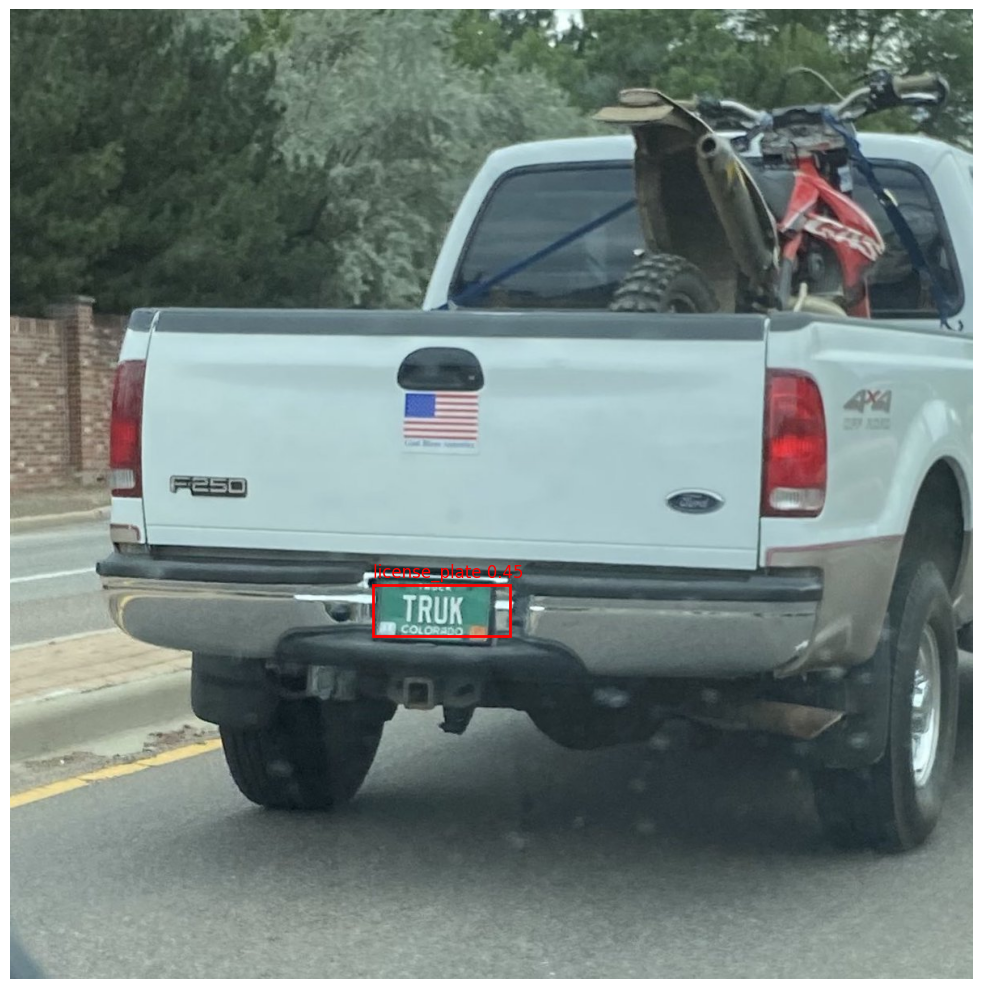

In [9]:
img = load_image("data/misc/us_plate.jpg")
detections = detect(img, localization_model, img_size=160, confidence_threshold=0.25)
for d in detections:
    class_name, conf, x1, y1, x2, y2 = d
    crop = crop_bbox(img, (x1, y1, x2, y2))
    #text = ocr(crop, processor, ocr_model)
    #print(f"Plate ({class_name}, {conf:.2f}): {text if text else '<no text>'}")

visualize(img, detections)

In [10]:
img = load_image("data/misc/croatian2.jpg")
detections = detect(img, localization_model, img_size=160, confidence_threshold=0.25)
for d in detections:
    class_name, conf, x1, y1, x2, y2 = d
    crop = crop_bbox(img, (x1, y1, x2, y2))
    text = ocr(crop, processor, ocr_model)
    print(f"Plate ({class_name}, {conf:.2f}): {text if text else '<no text>'}")

visualize(img, detections)

NameError: name 'processor' is not defined

In [11]:
img = load_image("data/misc/us1.jpg")
detections = detect(img, localization_model, img_size=160, confidence_threshold=0.25)
for d in detections:
    class_name, conf, x1, y1, x2, y2 = d
    crop = crop_bbox(img, (x1, y1, x2, y2))
    text = ocr(crop, processor, ocr_model)
    print(f"Plate ({class_name}, {conf:.2f}): {text if text else '<no text>'}")

visualize(img, detections)

NameError: name 'processor' is not defined

Plate (license_plate, 0.41): 9CSX356


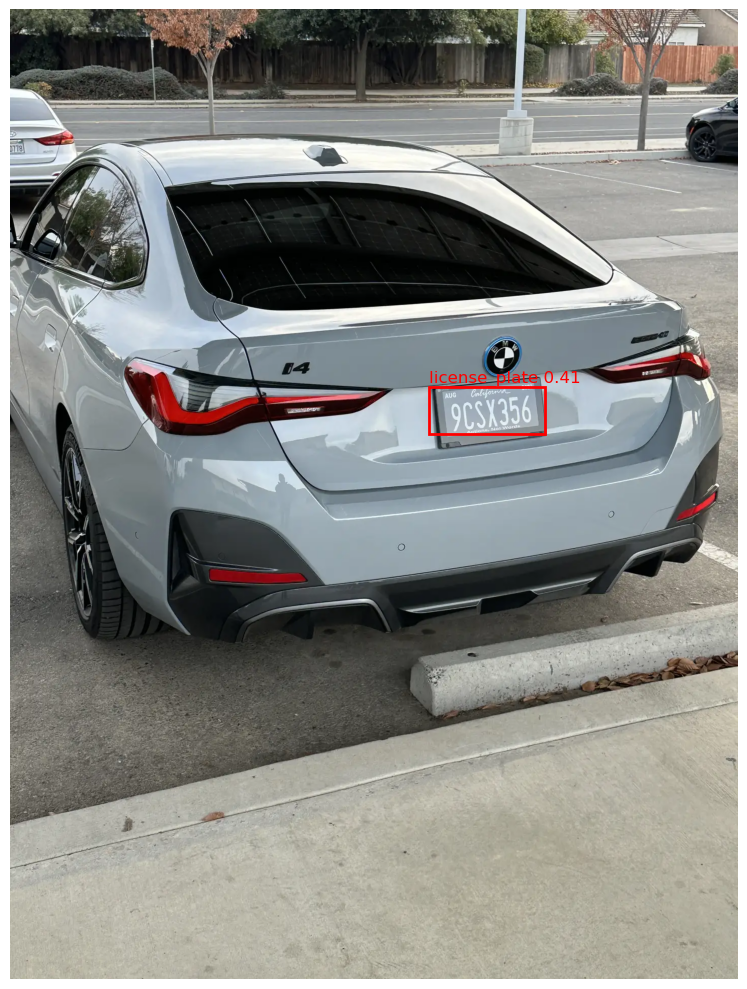

In [ ]:
img = load_image("data/misc/us2.webp")
detections = detect(img, localization_model, img_size=160, confidence_threshold=0.25)
for d in detections:
    class_name, conf, x1, y1, x2, y2 = d
    crop = crop_bbox(img, (x1, y1, x2, y2))
    text = ocr(crop, processor, ocr_model)
    print(f"Plate ({class_name}, {conf:.2f}): {text if text else '<no text>'}")

visualize(img, detections)

Plate (license_plate, 0.06): 0.60


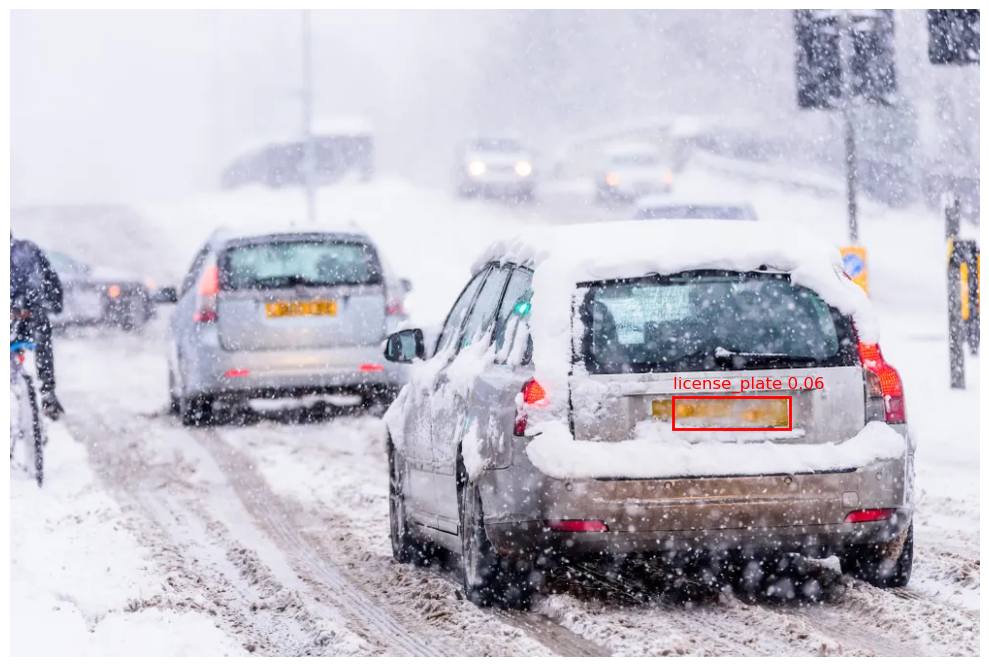

In [ ]:
img = load_image("data/misc/snow.webp")
detections = detect(img, localization_model, img_size=640, confidence_threshold=0.01)
for d in detections:
    class_name, conf, x1, y1, x2, y2 = d
    crop = crop_bbox(img, (x1, y1, x2, y2))
    text = ocr(crop, processor, ocr_model)
    print(f"Plate ({class_name}, {conf:.2f}): {text if text else '<no text>'}")

visualize(img, detections)

Plate (license_plate, 0.42): MYC FOR


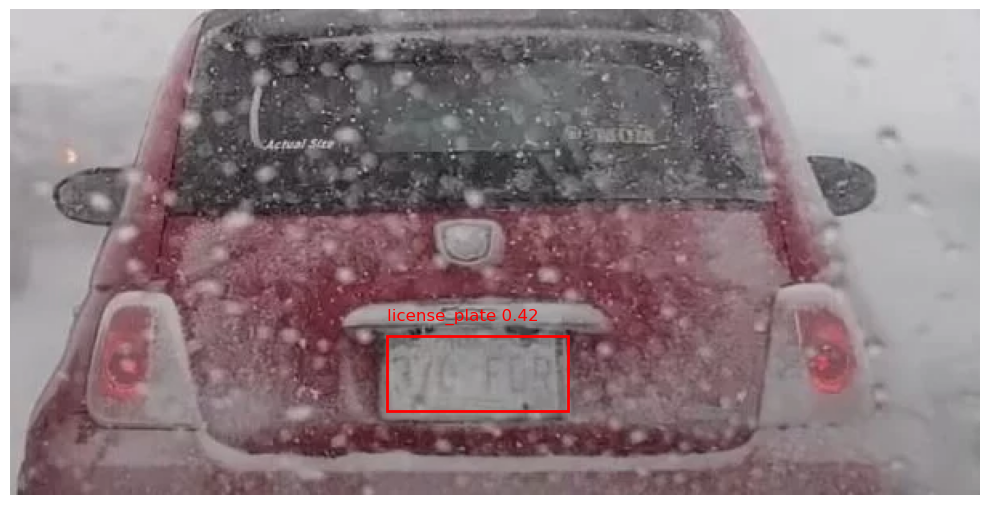

In [ ]:
img = load_image("data/misc/snow2.webp")
detections = detect(img, localization_model, img_size=160, confidence_threshold=0.25)
for d in detections:
    class_name, conf, x1, y1, x2, y2 = d
    crop = crop_bbox(img, (x1, y1, x2, y2))
    text = ocr(crop, processor, ocr_model)
    print(f"Plate ({class_name}, {conf:.2f}): {text if text else '<no text>'}")

visualize(img, detections)

In [12]:
class WeatherAugmentation:
    def __init__(self, weather_p=0.5, num_weather_corruptions=3):
        weather_effects = [
            A.RandomFog(fog_coef_range=(0.1, 0.5), alpha_coef=0.1, p=0.35),
            A.RandomRain(p=0.3),
            A.RandomSnow(snow_point_range=(0.3, 0.5), brightness_coeff=2.5, p=0.2),
            A.RandomSunFlare(p=0.2),
            A.RandomShadow(p=0.3),
            A.MotionBlur(blur_limit=(5, 20), p=0.4),
            A.GaussNoise(std_range=(0.01, 0.15), p=0.3),
            A.OneOf(
                [
                    A.RandomBrightnessContrast(
                        brightness_limit=(-0.4, 0.1), contrast_limit=(-0.2, 0.2), p=1.0
                    ),
                    A.RandomGamma(gamma_limit=(40, 180), p=1.0),
                ],
                p=0.5,
            ),
            A.Spatter(
                mode="mud", cutout_threshold=(0.7, 0.7), color=(120, 40, 40), p=0.2
            ),
        ]
        self.transform = A.Compose(
            [
                A.SomeOf(
                    weather_effects,
                    n=num_weather_corruptions,
                    replace=False,
                    p=weather_p,
                )
            ]
        )

    def __call__(self, labels):
        img = labels.get("img")
        if img is None:
            return labels

        is_float = img.dtype != np.uint8
        if is_float:
            img_u8 = (img * 255).clip(0, 255).astype(np.uint8)
        else:
            img_u8 = img

        img_rgb = np.ascontiguousarray(img_u8[:, :, ::-1])
        img_rgb = self.transform(image=img_rgb)["image"]
        result = np.ascontiguousarray(img_rgb[:, :, ::-1])

        labels["img"] = result.astype(np.float32) / 255.0 if is_float else result
        return labels

In [13]:
weather_effects = [
    A.RandomFog(fog_coef_range=(0.1, 0.5), alpha_coef=0.1, p=0.35),
    A.RandomRain(p=0.3),
    A.RandomSnow(snow_point_range=(0.3, 0.5), brightness_coeff=2.5, p=0.2),
    A.RandomSunFlare(p=0.2),
    A.RandomShadow(p=0.3),
    A.MotionBlur(blur_limit=(5, 20), p=0.4),
    A.GaussNoise(std_range=(0.01, 0.15), p=0.3),
    A.OneOf(
        [
            A.RandomBrightnessContrast(
                brightness_limit=(-0.4, 0.1), contrast_limit=(-0.2, 0.2), p=1.0
            ),
            A.RandomGamma(gamma_limit=(40, 180), p=1.0),
        ],
        p=0.5,
    ),
    A.Spatter(mode="mud", cutout_threshold=(0.7, 0.7), color=(120, 40, 40), p=0.2),
]
transform = A.Compose([A.SomeOf(weather_effects, n=3, replace=False, p=1.0)])

c:\Users\domag\Desktop\rac_vid_projekt\.venv\Lib\site-packages\albumentations\augmentations\blur\functional.py:232: UserWarning: blur_limit: Non-zero kernel sizes must be odd. Range (5, 20) automatically adjusted to (5, 21).
  result = _ensure_odd_values(result, info.field_name)


In [14]:
transform = A.Compose(
    [
        A.RandomFog(fog_coef_range=(0.1, 0.5), alpha_coef=0.1, p=1.0),
        A.RandomSnow(snow_point_range=(0.1, 0.2), brightness_coeff=1.5, p=1.0),
        A.RandomBrightnessContrast(
            brightness_limit=(-0.4, 0.1), contrast_limit=(-0.2, 0.2), p=1.0
        ),
    ]
)

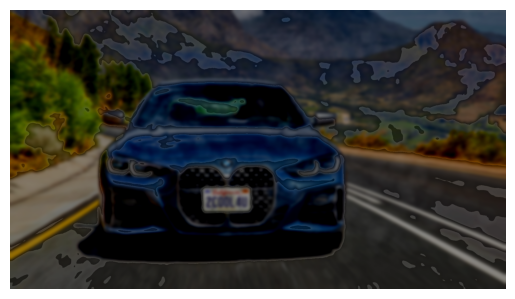

In [15]:
transformed_img = transform(image=img)["image"]
plt.imshow(transformed_img)
plt.axis("off")
plt.show()

In [16]:
img = load_image("data/testing/images/track0094[09].png")
detections = detect(img, localization_model, img_size=640, confidence_threshold=0.25)
for d in detections:
    class_name, conf, x1, y1, x2, y2 = d
    crop = crop_bbox(img, (x1, y1, x2, y2))
    text = ocr(crop, processor, ocr_model)
    print(f"Plate ({class_name}, {conf:.2f}): {text if text else '<no text>'}")

visualize(img, detections)

NameError: name 'processor' is not defined

In [17]:
img = load_image("data/testing/images/track0094[09].png")
detections = detect(img, localization_model, img_size=640, confidence_threshold=0.25)
for d in detections:
    class_name, conf, x1, y1, x2, y2 = d
    crop = crop_bbox(img, (x1, y1, x2, y2))
    text = ocr(crop, processor, ocr_model)
    print(f"Plate ({class_name}, {conf:.2f}): {text if text else '<no text>'}")

visualize(img, detections)

transformed_img = transform(image=img)["image"]
detections = detect(
    transformed_img, localization_model, img_size=640, confidence_threshold=0.25
)
for d in detections:
    class_name, conf, x1, y1, x2, y2 = d
    crop = crop_bbox(transformed_img, (x1, y1, x2, y2))
    text = ocr(crop, processor, ocr_model)
    print(f"Plate ({class_name}, {conf:.2f}): {text if text else '<no text>'}")

visualize(transformed_img, detections)

NameError: name 'processor' is not defined